# Simulation Comparison
Here, I consider a single latitude and mixed layer depth, and compare directly two simulations.

In [1]:
import copy
import sys
import os
import inspect
from matplotlib.lines import Line2D
import scipy.optimize
from scipy.interpolate import CubicSpline, UnivariateSpline

from isca_tools.papers.miyawaki_2022 import get_dmse_dt
from isca_tools.plot.base import line_masked_lw
from isca_tools.thesis.adiabat_theory import get_z_ft_approx
from isca_tools.thesis.profile_fitting import get_tropopause_lev_ind
from isca_tools.utils.base import mass_weighted_vertical_integral
from isca_tools.utils.fourier import coef_conversion, fourier_series
from isca_tools.utils.numerical import get_var_shift, spline_deriv_periodic, fit_linear_zero_mean
from isca_tools.utils.xarray import wrap_with_apply_ufunc, update_dim_slice, transpose_common_dims_like
from matplotlib.ticker import FuncFormatter, FixedLocator

# REMOTE - So can access functions in isca_tools which is in home/Isca directory
# sys.path.append(os.path.join(os.environ['HOME'], 'Isca'))
# LOCAL - So can access functions in isca_tools which is in StAndrews/Isca
sys.path.append(os.environ['PWD'])
import isca_tools
from isca_tools.utils.moist_physics import clausius_clapeyron_factor, sphum_sat, get_density
from isca_tools.utils.constants import kappa, L_v, c_p, c_p_ocean, rho_ocean, Stefan_Boltzmann, R, R_v, g
from isca_tools.utils.radiation import get_heat_capacity, frierson_sw_optical_depth, opd_lw_gray
from isca_tools.plot import colored_line, line_masked_lw
from isca_tools.thesis.surface_energy_budget_2layer2 import get_feedback_params_analytic, get_heat_cap_lambda_eff
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
from tqdm.notebook import tqdm
from isca_tools.plot import fig_resize, update_fontsize, update_linewidth, savefig, label_subplots

from jobs.thesis_season.thesis_figs.utils import get_fourier_fit_xr, polyfit_phase_xr
import jobs.thesis_season.column.utils as utils

# Use custom matplotlib style for publishing
plt.style.use('/Users/joshduffield/Documents/StAndrews/Isca/jobs/tau_sweep/aquaplanet/publish_figures/publish.mplstyle')
ax_linewidth = plt.rcParams['axes.linewidth']

In [45]:
depth_use = 20  # 5 or 20
lat_use = 40
take_annual_harmonic = True  # whether to take annual harmonic of all variables from outset or not
exp_name = ['no_wind_dry', 'sw_dry', 'wind_moist', 'sw_wind_moist']
n_exp = len(exp_name)
ds_base = []
exp_sphum_set0 = []
varying_attrs = ['drag_coef', 'rh_flux_q', 'odp_sw', 'sw_abs', 'albedo']
for i in tqdm(range(n_exp)):
    ds_base.append(utils.load_ds(exp_name=f"thesis_season/column/depth={depth_use}/{exp_name[i]}", lat_min=30,
                                 var_keep=utils.var_keep + ['drag_q', 'olr', 'sphum'], low_lev_only=False,
                                 first_month_file=2).sel(lat=lat_use, method="nearest"))
    if 'sphum' not in ds_base[i]:
        ds_base[i]['sphum'] = ds_base[i]['temp'] * 0
        exp_sphum_set0.append(exp_name[i])
    # Add attributes as these can vary between experiments
    for var in varying_attrs:
        if var in ds_base[i].attrs:
            ds_base[i][var] = ds_base[i].attrs[var]
if len(exp_sphum_set0) > 0:
    print(f'Set sphum=0 for {exp_sphum_set0}')

exp_name = xr.DataArray(exp_name, dims="exp", name='exp')
ds_base = xr.concat(ds_base, dim=exp_name).squeeze()

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

In [3]:
def get_p_eff(p_surf, temp=280, lapse_rate=6.5 / 1000):
    # Characteristic pressure for the q^* distribution, accounts for more q^* near the surface
    p_alpha_calc = 1000 * 100  # clausius clapeyron parameter is insensitive to pressure
    beta = clausius_clapeyron_factor(temp, p_alpha_calc) * lapse_rate * R * temp / g
    return (beta + 1) / (beta + 2) * p_surf


def get_temp_from_sphum_sat(sphum_sat_target, p, guess_temp: float = 280):
    fit_func = lambda x: sphum_sat(x, p) - sphum_sat_target
    return scipy.optimize.fsolve(fit_func, np.full_like(sphum_sat_target, guess_temp))


get_temp_from_sphum_sat_xr = wrap_with_apply_ufunc(get_temp_from_sphum_sat, input_core_dims=[[], []],
                                                   output_core_dims=[[]])

## Compute relevant temperatures
Below, I compute the column and specific humidity weighted temperatures, and also empirically relate these as well as the surface and OLR radiative temperatures to the lowest model level temperature.

In [4]:
ds_base['p_lev'] = ds_base.sigma_atm * ds_base.p_surf.max()
ds_base['temp_col'] = mass_weighted_vertical_integral(ds_base.temp, ds_base.p_lev, 'pfull', simpson_method=True)
ds_base['sphum_col'] = mass_weighted_vertical_integral(ds_base.sphum, ds_base.p_lev, 'pfull', simpson_method=True)
ds_base['rh_col'] = ds_base['sphum_col'] / mass_weighted_vertical_integral(sphum_sat(ds_base.temp, ds_base.p_lev),
                                                                           ds_base.p_lev, 'pfull', simpson_method=True)
ds_base['p_eff'] = get_p_eff(ds_base.p_surf.max(dim=['time']))
ds_base['temp_col_sphum'] = get_temp_from_sphum_sat_xr(ds_base.sphum_col / ds_base.rh_col, ds_base.p_eff)

for i in range(n_exp):
    if 'dry' in exp_name[i]:
        # If no wind, there is very little column humidity, so this gives the best approx
        ds_base.isel(exp=i)['rh_col'] *= 0

ds = utils.get_annual_zonal_mean(ds_base.expand_dims('lon'))
if take_annual_harmonic:
    # Take annual harmonic of all variables for simplicity
    for key in ds:
        if 'time' in ds[key].dims:
            try:
                ds[key] = get_fourier_fit_xr(ds.time, ds[key], n_harmonics=1, pad_coefs_phase=True)[0]
            except ValueError:
                print(key)

q_surf


In [5]:
coef_temp = {'amp': {}, 'phase': {}}
for key in ['col', 'col_sphum', 'rad_atm', 'rad_surf']:
    coef_temp['amp'][key], coef_temp['phase'][key] = utils.get_fit_coef_complex(ds[f"temp_{key}"], ds.temp_atm, ds.time)

## $\lambda$ feedback parameters
### Empirical
Below I find the feedback parameters through empirical means.

In [6]:
spline_deriv_xr = utils.wrap_with_apply_ufunc(spline_deriv_periodic,
                                              input_core_dims=[['time'], ['time']],
                                              output_core_dims=[['time']])

def get_fit_coef(x, y):
    # Returns single fitting coefficient, i.e., c such that y=cx
    return polyfit_phase_xr(x - x.mean(dim='time'), y - y.mean(dim='time'),
                            1, include_phase=False, coef_fix=[None, None, 0]).sel(deg='1')

In [7]:
fit_linear_zero_mean_xr_1 = utils.wrap_with_apply_ufunc(
    lambda x1, y: fit_linear_zero_mean(x1, y, x2=None)[0],
    input_core_dims=[['time'], ['time']],
    output_core_dims=[[]],
)

fit_linear_zero_mean_xr_2 = utils.wrap_with_apply_ufunc(
    lambda x1, y, x2: fit_linear_zero_mean(x1, y, x2=x2),
    input_core_dims=[['time'], ['time'], ['time']],
    output_core_dims=[[], []],
)


def get_fit_coef(x1, y, x2=None):
    # Returns single fitting coefficient, i.e., c such that y=cx
    if x2 is None:
        return fit_linear_zero_mean_xr_1(x1 - x1.mean(dim='time'), y - y.mean(dim='time'))
    else:
        return fit_linear_zero_mean_xr_2(x1 - x1.mean(dim='time'), y - y.mean(dim='time'), x2 - x2.mean(dim='time'))

In [8]:
feedback_params = {'empirical': {}, 'analytic': {}}
feedback_params['empirical']['mu'] = get_fit_coef(spline_deriv_xr(ds.time * utils.day_seconds, ds.temp_atm),
                                                  spline_deriv_xr(ds.time * utils.day_seconds,
                                                                  ds.sphum_col)) * L_v / c_p
lambda_lh_cont, feedback_params['empirical']['lambda_lh'] = get_fit_coef(ds.temp_surf - ds.temp_atm, ds.flux_lhe,
                                                                         ds.temp_atm)
lambda_sh_cont, feedback_params['empirical']['lambda_sh'] = get_fit_coef(ds.temp_surf - ds.temp_atm, ds.flux_t,
                                                                         -ds.temp_atm)
lambda_lw_cont, feedback_params['empirical']['lambda_lw2'] = get_fit_coef(ds.temp_surf - ds.temp_atm,
                                                                          ds.lwup_sfc - ds.lwdn_sfc, ds.temp_atm)
feedback_params['empirical']['lambda_const'] = lambda_lh_cont + lambda_sh_cont + lambda_lw_cont
olr_surf_cont = Stefan_Boltzmann * np.exp(-ds.odp_surf) * ds.temp_surf ** 4
feedback_params['empirical']['lambda_lw1'] = get_fit_coef(ds.temp_surf, olr_surf_cont)
feedback_params['empirical']['B'], feedback_params['empirical']['coef_phase_olr'] = \
    utils.get_fit_coef_complex(ds.olr - olr_surf_cont, ds.temp_atm, ds.time)
feedback_params['empirical']['coef_amp_col'] = coef_temp['amp']['col']
feedback_params['empirical']['coef_phase_col'] = coef_temp['phase']['col']

In [9]:
_, coef_amp, coef_phase = get_fourier_fit_xr(ds.time, ds.temp_surf, n_harmonics=1, pad_coefs_phase=True)
_, coef_sw_amp, coef_sw_phase = get_fourier_fit_xr(ds.time, ds.swdn_sfc, n_harmonics=1, pad_coefs_phase=True)
coef_amp = np.abs(coef_amp.sel(harmonic=1))
coef_phase = coef_phase.sel(harmonic=1)
coef_sw_amp = np.abs(coef_sw_amp.sel(harmonic=1))

f = 1 / (ds.time.size * utils.day_seconds)
omega = 2 * np.pi / (utils.day_seconds * ds.time.size)
heat_cap_multiplier = get_heat_capacity(c_p_ocean, rho_ocean,
                                        coef_sw_amp * np.sin(coef_phase) / (2 * np.pi * f) / coef_amp,
                                        True) / ds.depth
heat_capacity_eff = ds.heat_capacity * heat_cap_multiplier
lambda_s1_eff = coef_sw_amp * np.cos(coef_phase) / coef_amp

### Analytic
Below I use analytic Taylor series approximations for the feedback parameters, before comparing the two.

In [10]:
# Different method, sanity check that gives same results
# Defined the lambda parameters differently as to be more in keeping with literature.
# Now have some feedback parameters which are expected to be small
ds_use = ds.mean(dim='time', keep_attrs=True)
arg_names = list(inspect.signature(get_feedback_params_analytic).parameters.keys())
args_use = {key: ds_use[key] for key in arg_names if key in ds_use}
args_use['sigma_atm'] = args_use['sigma_atm'].sel(pfull=np.inf, method='nearest')
args_use['drag_coef'] = ds_use.drag_coef
args_use['pressure_heat_cap_atmos_calc'] = float(ds['p_lev'].max() - ds['p_lev'].min())
args_use['p_col_sphum'] = ds_use.p_eff
args_use['coef_amp_rad_surf'] = coef_temp['amp']['rad_surf']
args_use['coef_amp_olr'] = coef_temp['amp']['rad_atm']
args_use['coef_amp_col_sphum'] = coef_temp['amp']['col_sphum']

var = get_feedback_params_analytic(**args_use)
feedback_params['analytic'] = {'mu': None, 'lambda_const': None, 'B': None, 'lambda_sh': None, 'lambda_lh': None,
                               'lambda_lw1': None, 'lambda_lw2': None}
for i, key in enumerate(feedback_params['analytic']):
    feedback_params['analytic'][key] = var[i]
feedback_params['analytic']['coef_amp_col'] = coef_temp['amp']['col']
feedback_params['analytic']['coef_phase_col'] = coef_temp['phase']['col']
feedback_params['analytic']['coef_phase_olr'] = coef_temp['phase']['rad_atm']

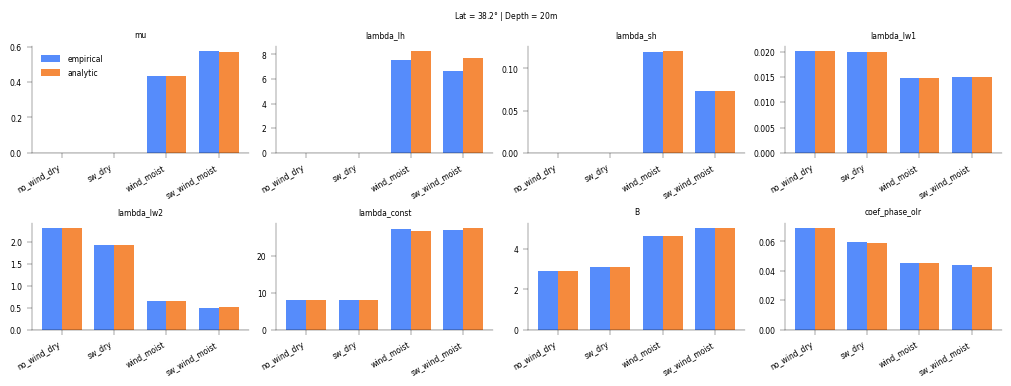

In [11]:
def plot_feedback_params(feedback_params, params=None, ncols=3, figsize_per_panel=(4, 3)):
    """Plot empirical vs analytic feedback parameters for each experiment.

    Args:
        feedback_params: Dict with top-level keys 'empirical' and 'analytic'.
        params: List of parameter names to plot. If None, use common keys.
        ncols: Number of subplot columns.
        figsize_per_panel: Width, height per subplot.

    Returns:
        fig, axs
    """
    empirical = feedback_params['empirical']
    analytic = feedback_params['analytic']

    if params is None:
        params = [k for k in empirical if k in analytic]

    exps = empirical[params[0]]['exp'].values
    nparams = len(params)
    nrows = int(np.ceil(nparams / ncols))

    fig, axs = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        constrained_layout=True,
        squeeze=False,
    )

    x = np.arange(len(exps))
    width = 0.38

    for i, param in enumerate(params):
        ax = axs.flat[i]

        emp = empirical[param].sel(exp=exps).values
        ana = analytic[param].sel(exp=exps).values

        ax.bar(x - width / 2, emp, width, label='empirical')
        ax.bar(x + width / 2, ana, width, label='analytic')

        ax.set_title(param)
        ax.set_xticks(x)
        ax.set_xticklabels(exps, rotation=30, ha='right')

        if i == 0:
            ax.legend()

        ax.axhline(0, color='k', linewidth=0.8)

    for j in range(nparams, axs.size):
        axs.flat[j].set_visible(False)

    return fig, axs


fig, axs = plot_feedback_params(feedback_params,
                                params=['mu', 'lambda_lh', 'lambda_sh', 'lambda_lw1', 'lambda_lw2', 'lambda_const', 'B',
                                        'coef_phase_olr'], ncols=4)
fig_resize(fig, 10)
fig.suptitle(f'Lat = {ds.lat.values:.1f}$\degree$ | Depth = {ds.depth.values:.0f}m')
update_fontsize(fig)
plt.show()

## Approx Solution
Below I use the approximations for the feedback parameters to construct a solution for temperature. I compare both the effective heat capacity and feedback parameters to the direct values. I also compare the amplitude and phase to the direct values too.

In [12]:
def get_theory_quantities(feedback_params_dict, heat_capacity_surf=float(ds.heat_capacity.isel(exp=0)), albedo=ds.albedo, sw_abs=ds.sw_abs,
                          pressure_heat_cap_atmos_calc=args_use['pressure_heat_cap_atmos_calc'],
                          omega=omega, coef_sw_amp=coef_sw_amp):
    """Computes the four theoretical quantities from a set of feedback parameters.

    Given a dictionary of feedback parameters, this calls `get_heat_cap_lambda_eff`
    and combines the outputs with dataset/argument info to return the four
    quantities of interest.

    Args:
        feedback_params_dict (dict): Dictionary of feedback parameters, e.g.
            a single entry of `feedback_params[params_use]`, containing keys
            such as `mu`, `lambda_const`, `B`, `lambda_sh`, `lambda_lh`,
            `lambda_lw1`, `lambda_lw2`, `coef_amp_col`, `coef_phase_col`,
            `coef_phase_olr`.
        ds: Dataset containing `heat_capacity`, `albedo`, `sw_abs`.
        pressure_heat_cap_atmos_calc:
        omega (float): Angular frequency of forcing, $\omega$.
        coef_sw_amp (float): Amplitude coefficient of shortwave forcing.

    Returns:
        tuple: `(lambda_s1_eff, heat_cap_mult, coef_phase, coef_amp)`.
    """
    lambda_mult, heat_cap_mult = get_heat_cap_lambda_eff(
        **feedback_params_dict, heat_cap_surf=heat_capacity_surf,
        pressure_heat_cap_atmos_calc=pressure_heat_cap_atmos_calc,
        albedo=albedo, sw_abs=sw_abs
    )
    lambda_eff = feedback_params_dict['lambda_const'] * lambda_mult
    heat_capacity_eff = heat_capacity_surf * heat_cap_mult
    coef_phase = np.arctan2(omega * heat_capacity_eff, lambda_eff)
    coef_amp = coef_sw_amp / np.sqrt(omega ** 2 * heat_capacity_eff ** 2 + lambda_eff ** 2)
    return lambda_eff, heat_cap_mult, coef_phase, coef_amp


def get_param_contributions(feedback_params_all, heat_capacity_surf=ds.heat_capacity,
                            albedo=ds.albedo, sw_abs=ds.sw_abs,
                            pressure_heat_cap_atmos_calc=args_use['pressure_heat_cap_atmos_calc'],
                            omega=omega, coef_sw_amp=coef_sw_amp,
                            params_to_vary=('mu', 'lambda_sh', 'lambda_lh',
                                            'lambda_lw1', 'lambda_lw2',
                                            'coef_phase_col', 'coef_phase_olr')):
    """Decomposes the theoretical quantities into per-parameter contributions.

    For each parameter in `params_to_vary`, this sets all parameters in
    `params_to_vary` to zero except one, computes the resulting theoretical
    quantities, and records the difference relative to the baseline where
    all of `params_to_vary` are zero. A residual term is also computed as
    the difference between the true (all non-zero) result and the sum of
    the baseline plus all individual contributions, capturing interaction
    effects between parameters, i.e.

    $\text{residual} = f(\text{all nonzero}) - f(\text{all zero}) - \sum_i \Delta_i$

    Args:
        feedback_params_all (dict): Full dictionary of feedback parameters
            (all non-zero), containing all keys in `params_to_vary` plus
            any others (e.g. `lambda_const`) needed by `get_heat_cap_lambda_eff`.
        ds: Dataset containing `heat_capacity`, `albedo`, `sw_abs`.
        args_use (dict): Dictionary containing `pressure_heat_cap_atmos_calc`.
        omega (float): Angular frequency of forcing, $\omega$.
        coef_sw_amp (float): Amplitude coefficient of shortwave forcing.
        params_to_vary (tuple): Names of parameters whose contributions are
            to be decomposed.

    Returns:
        dict: Dictionary with keys `lambda_s1_eff`, `heat_capacity_eff`,
            `coef_phase`, `coef_amp`, each mapping to a dict with keys
            matching `params_to_vary` plus `'residual'`, giving the
            contribution of each parameter to that quantity.
    """
    quantity_names = ('lambda_eff', 'heat_cap_mult', 'coef_phase', 'coef_amp')
    contributions = {q: {} for q in quantity_names}

    # Baseline: all params_to_vary set to zero
    params_zero = dict(feedback_params_all)
    for key in params_to_vary:
        params_zero[key] = 0
    baseline = get_theory_quantities(params_zero, heat_capacity_surf, albedo, sw_abs,
                                     pressure_heat_cap_atmos_calc, omega, coef_sw_amp)

    # One-at-a-time contributions
    for key in params_to_vary:
        params_single = dict(params_zero)
        params_single[key] = feedback_params_all[key]
        result_single = get_theory_quantities(params_single, heat_capacity_surf, albedo, sw_abs,
                                              pressure_heat_cap_atmos_calc, omega, coef_sw_amp)
        for q, base_val, single_val in zip(quantity_names, baseline, result_single):
            contributions[q][key] = single_val - base_val

    # Full (all non-zero) result and residual
    full_result = get_theory_quantities(feedback_params_all, heat_capacity_surf, albedo, sw_abs,
                                        pressure_heat_cap_atmos_calc, omega, coef_sw_amp)
    for q, base_val, full_val in zip(quantity_names, baseline, full_result):
        sum_individual = sum(contributions[q][key] for key in params_to_vary)
        contributions[q]['residual'] = full_val - base_val - sum_individual

    return contributions

In [13]:
params_use = 'empirical'
lambda_eff_theory, heat_cap_multiplier_theory, coef_phase_theory, coef_amp_theory = \
    get_theory_quantities(feedback_params[params_use])
tan_phase_theory = np.tan(coef_phase_theory)
heat_capacity_eff_theory = heat_cap_multiplier_theory * ds.heat_capacity

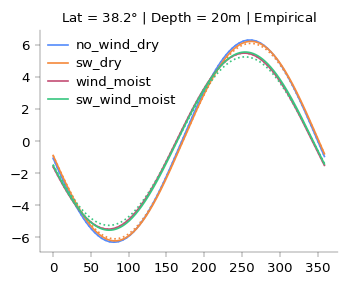

In [14]:
fig, ax = plt.subplots(1, 1, sharex=True, sharey=True)
fig_resize(fig, utils.width['two_col'] * 0.7)
for i in range(ds.exp.size):
    ds_use = ds.isel(exp=i)
    ax.plot(ds.time, ds_use.temp_surf - ds_use.temp_surf.mean(dim='time'), color=f"C{i}", label=f"{ds.exp[i].values}")
    amp_theory_use = coef_amp_theory.isel(exp=i)
    phase_theory_use = coef_phase_theory.isel(exp=i)
    ax.plot(ds.time, fourier_series(ds.time, [0, -amp_theory_use],
                                    [0, phase_theory_use], pad_coefs_phase=True), color=f"C{i}", linestyle=':')
update_linewidth(fig)
ax.legend()
ax.set_title(f'Lat = {ds.lat.values:.1f}$\degree$ | Depth = {ds.depth.values:.0f}m | {params_use.capitalize()}')
update_fontsize(fig)
plt.show()

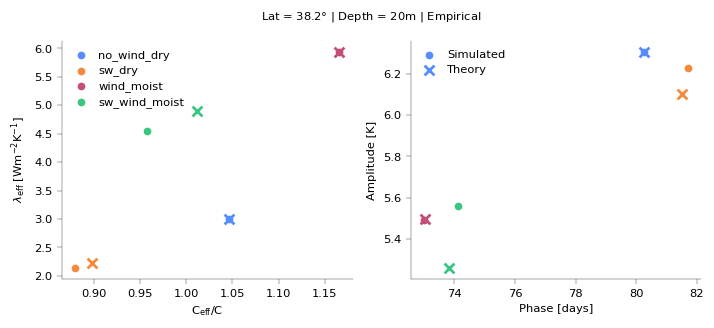

In [15]:
show_phase_time = True
fig, ax = plt.subplots(1, 2)
fig_resize(fig, utils.width['two_col'] * 1.5)
for i in range(ds.exp.size):
    ax[0].scatter(heat_cap_multiplier.isel(exp=i), lambda_s1_eff.isel(exp=i), color=f'C{i}',
                  label=f'{ds.exp[i].values}',
                  marker='.', s=50, lw=2)
    ax[0].scatter(heat_cap_multiplier_theory.isel(exp=i), lambda_eff_theory.isel(exp=i),
                  color=f'C{i}', marker='x', s=50, lw=2)
    ax[1].scatter(coef_phase.isel(exp=i) / omega / utils.day_seconds if show_phase_time else
                  (omega * heat_capacity_eff / lambda_s1_eff).isel(exp=i), coef_amp.isel(exp=i),
                  color=f'C{i}', marker='.', s=50, lw=2, label='Simulated' if i == 0 else None)
    ax[1].scatter(np.arctan(tan_phase_theory).isel(exp=i) / omega / utils.day_seconds if show_phase_time else
                  tan_phase_theory.isel(exp=i), coef_amp_theory.isel(exp=i),
                  color=f'C{i}', marker='x', s=50, lw=2, label='Theory' if i == 0 else None)
    # ax[0].plot(ds.lat, heat_cap_multiplier_theory.isel(exp=i), color=f'C{i}', linestyle=':')
    # ax[1].plot(ds.lat, lambda_s1_eff.isel(exp=i), color=f'C{i}', label='Simulated' if i == 0 else None)
    # ax[1].plot(ds.lat, lambda_s1_eff_theory.isel(exp=i), color=f'C{i}', linestyle=':',
    #            label='Theory' if i == 0 else None)
update_linewidth(fig)
ax[0].legend()
ax[1].legend()
ax[0].set_xlabel("C$_{\\text{eff}}/$C")
ax[0].set_ylabel("$\lambda_{\\text{eff}}$ [Wm$^{-2}\\text{K}^{-1}$]")
ax[1].set_xlabel("Phase [days]" if show_phase_time else "$\\tan (\\phi)$")
ax[1].set_ylabel("Amplitude [K]")
fig.suptitle(f'Lat = {ds.lat.values:.1f}$\degree$ | Depth = {ds.depth.values:.0f}m | {params_use.capitalize()}')
update_fontsize(fig, 7)
plt.show()

## Breakdown contribution from each parameter
Naively, we may expect all the parameters to be zero, except for $B$ and $\lambda$. This is the typical two layer model. Below I look at the individual effects of each of the other parameters on the total phase and amplitude.

In [16]:
contributions = get_param_contributions(feedback_params[params_use])

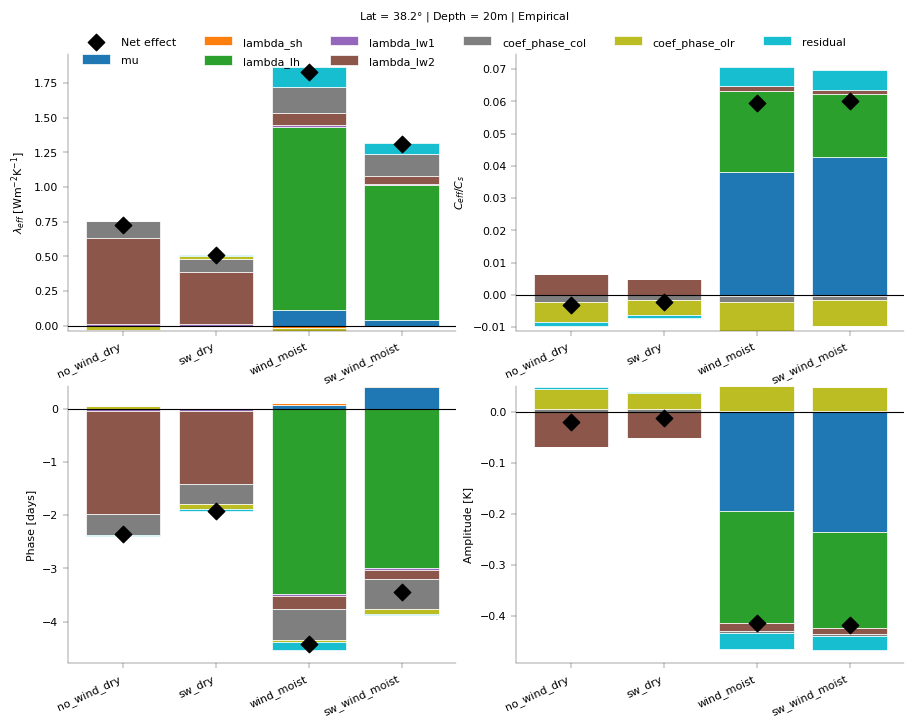

In [17]:
def plot_contribution_bars_grid(contributions, exps, titles=None, save_path='output/contributions_grid_mpl.png'):
    """Plots a 2x2 grid of stacked bar charts with net-effect markers.

    For each quantity, draws one stacked bar per experiment (segments = each
    parameter's contribution, positive/negative stacked separately), and
    overlays a scatter marker showing the net effect (sum of all contributions
    including the residual) for each experiment.

    Args:
        contributions (dict): Nested dict `{quantity_name: {param_name: array_like}}`
            with 4 quantities, each parameter array of shape `(n_exp,)`.
        exps (list of str): Experiment names, used as x-axis tick labels.
        titles (dict, optional): Maps `quantity_name` to a subplot title.
        save_path (str): File path to save the combined PNG figure.

    Returns:
        matplotlib.figure.Figure: The combined 2x2 figure.
    """
    titles = titles or {}
    x = np.arange(len(exps))
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for ax, (qty, params_dict) in zip(axes, contributions.items()):
        df = pd.DataFrame(params_dict, index=exps)
        colors = plt.cm.tab10(np.linspace(0, 1, len(df.columns)))

        pos_base = np.zeros(len(exps))
        neg_base = np.zeros(len(exps))

        for color, param in zip(colors, df.columns):
            vals = df[param].values
            if qty == 'coef_phase':
                vals = vals / omega / utils.day_seconds  # convert into a time
            pos_vals = np.where(vals > 0, vals, 0)
            neg_vals = np.where(vals < 0, vals, 0)
            ax.bar(x, pos_vals, bottom=pos_base, color=color, label=param,
                   edgecolor='white', linewidth=0.5)
            ax.bar(x, neg_vals, bottom=neg_base, color=color,
                   edgecolor='white', linewidth=0.5)
            pos_base += pos_vals
            neg_base += neg_vals

        # Net effect = sum of all contributions (incl. residual) = true total
        net_effect = df.sum(axis=1).values
        if qty == 'coef_phase':
            net_effect = net_effect / omega / utils.day_seconds  # convert into a time
        ax.scatter(x, net_effect, color='black', marker='D', s=70, zorder=5,
                   label='Net effect')

        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(exps, rotation=25, ha='right', fontsize=10)
        # ax.set_ylabel('Contribution', fontsize=11)
        ax.set_ylabel(titles.get(qty, qty), fontsize=13)
        ax.tick_params(axis='y', labelsize=10)

    # Single shared legend for the whole figure (avoids repeating per subplot)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.03),
               ncol=6, fontsize=10, frameon=False)
    # fig.suptitle('Parameter Contributions to Theoretical Quantities', fontsize=15, y=1.08)
    fig.tight_layout()
    return fig


exps = ['no_wind_dry', 'sw_dry', 'wind_moist', 'sw_wind_moist']
titles = {
    'lambda_eff': '$\\lambda_{eff}$ [Wm$^{-2}\\text{K}^{-1}$]',
    'heat_cap_mult': '$C_{eff}/C_s$',
    'coef_phase': 'Phase [days]',
    'coef_amp': 'Amplitude [K]',
}

fig = plot_contribution_bars_grid(contributions, exps, titles=titles)
fig.suptitle(f'Lat = {ds.lat.values:.1f}$\degree$ | Depth = {ds.depth.values:.0f}m | {params_use.capitalize()}', y=1.05)
fig_resize(fig, 9)
update_fontsize(fig, 5)
plt.show()

In [18]:
def get_param_contributions_diff(feedback_params_all, exp0, exp1,
                                 heat_capacity_surf=ds.heat_capacity,
                                 albedo=ds.albedo, sw_abs=ds.sw_abs,
                                 pressure_heat_cap_atmos_calc=args_use['pressure_heat_cap_atmos_calc'],
                                 omega=omega, coef_sw_amp=coef_sw_amp,
                                 params_to_vary=('lambda_const', 'B', 'mu', 'lambda_sh', 'lambda_lh',
                                                 'lambda_lw2', 'coef_amp_col', 'lambda_lw1', 'coef_phase_olr', 'coef_phase_col')):
    """Decomposes the difference between two experiments into per-parameter contributions.

    Rather than comparing to a zero baseline, this takes `exp0` as the
    reference state and, for each parameter in `params_to_vary`, swaps only
    that parameter from its `exp0` value to its `exp1` value (holding all
    other parameters at `exp0`), then computes the resulting change in each
    theoretical quantity. A residual term captures interaction effects
    between parameters not explained by the sum of individual swaps, i.e.

    $\text{residual} = f(\text{exp1}) - f(\text{exp0}) - \sum_i \Delta_i$

    Args:
        feedback_params_all (dict): Full dictionary of feedback parameters,
            where each value is an `xarray.DataArray` with a dimension `exp`
            containing at least `exp0` and `exp1` as coordinate labels.
        exp0 (str): Coordinate label of the reference experiment.
        exp1 (str): Coordinate label of the comparison experiment.
        heat_capacity_surf, albedo, sw_abs: Fields passed to
            `get_heat_cap_lambda_eff`, each with an `exp` dimension matching
            `feedback_params_all`.
        pressure_heat_cap_atmos_calc: Passed through to `get_heat_cap_lambda_eff`.
        omega (float): Angular frequency of forcing, $\omega$.
        coef_sw_amp (float): Amplitude coefficient of shortwave forcing.
        params_to_vary (tuple): Names of parameters whose contributions to
            the exp1 minus exp0 difference are to be decomposed.

    Returns:
        dict: Dictionary with keys `lambda_eff`, `heat_cap_mult`,
            `coef_phase`, `coef_amp`, each mapping to a dict with keys
            matching `params_to_vary` plus `'residual'`, giving the
            contribution of each parameter to the exp1 minus exp0
            difference in that quantity.
    """
    quantity_names = ('lambda_eff', 'heat_cap_mult', 'coef_phase', 'coef_amp')
    contributions = {q: {} for q in quantity_names}

    def sel_exp(field, exp):
        return field.sel(exp=exp) if hasattr(field, 'sel') else field

    # Reference state: everything at exp0
    params_exp0 = {key: sel_exp(val, exp0) for key, val in feedback_params_all.items()}
    hc_surf0 = sel_exp(heat_capacity_surf, exp0)
    albedo0 = sel_exp(albedo, exp0)
    sw_abs0 = sel_exp(sw_abs, exp0)
    result_exp0 = get_theory_quantities(params_exp0, hc_surf0, albedo0, sw_abs0,
                                        pressure_heat_cap_atmos_calc, omega, coef_sw_amp)

    # Comparison state: everything at exp1
    params_exp1 = {key: sel_exp(val, exp1) for key, val in feedback_params_all.items()}
    hc_surf1 = sel_exp(heat_capacity_surf, exp1)
    albedo1 = sel_exp(albedo, exp1)
    sw_abs1 = sel_exp(sw_abs, exp1)
    result_exp1 = get_theory_quantities(params_exp1, hc_surf1, albedo1, sw_abs1,
                                        pressure_heat_cap_atmos_calc, omega, coef_sw_amp)

    # One-at-a-time contributions: swap the param (and lambda_const, unless
    # the param IS lambda_const) from exp0 to exp1
    for key in params_to_vary:
        params_swap = dict(params_exp0)
        params_swap[key] = params_exp1[key]
        if key != 'lambda_const':
            params_swap['lambda_const'] = params_exp1['lambda_const']
        result_swap = get_theory_quantities(params_swap, hc_surf0, albedo0, sw_abs0,
                                            pressure_heat_cap_atmos_calc, omega, coef_sw_amp)
        for q, base_val, swap_val in zip(quantity_names, result_exp0, result_swap):
            contributions[q][key] = swap_val - base_val
    for key in params_to_vary:
        if key != 'lambda_const':
            for q in quantity_names:
                # So to avoid double counting lambda change
                contributions[q][key] -= contributions[q]['lambda_const']

    # Residual: total difference minus sum of individual contributions
    for q, val0, val1 in zip(quantity_names, result_exp0, result_exp1):
        total_diff = val1 - val0
        sum_individual = sum(contributions[q][key] for key in params_to_vary)
        contributions[q]['residual'] = total_diff - sum_individual

    return contributions

In [19]:
cont_diff = get_param_contributions_diff(feedback_params[params_use], 'no_wind_dry', 'wind_moist',
                             heat_capacity_surf=float(ds.heat_capacity.isel(exp=0)), sw_abs=float(ds.sw_abs.isel(exp=0)),
                             albedo=float(ds.albedo.isel(exp=0)),
                             coef_sw_amp=float(coef_sw_amp.isel(exp=0)))
cont_diff_use = {}
for key in cont_diff:
    cont_diff_use[key] = {'$\\lambda$': cont_diff[key]['lambda_const'], '$B$': cont_diff[key]['B'],
                          '$\\lambda_a$': cont_diff[key]['lambda_lh'] + cont_diff[key]['lambda_lw2'] - cont_diff[key]['lambda_sh'],
                          '$C_a$': cont_diff[key]['mu'] + cont_diff[key]['coef_amp_col'],
                          'residual': cont_diff[key]['residual']}


### Effect of including latent heat.

Below I compare the latent heat simulation to the simulation with no latent heat.

Get big increase in $B$ because with wind included big increase in $\beta$ such that $T_{rad_a} = \beta T_a$. I think this is mainly because atmosphere is now much more coupled to the surface with latent heat.

Get big increase in $C_a$ because now have non zero $\mu$ - makes it 1.5 times bigger.

Here $C_a$ incoporates the effects of $\beta_{col}$ and $\mu$; while $\lambda_a$ incoporates the effects of $\lambda_{lh}$, $\lambda_{sh}$, and $\lambda_{lw2}$.

Residual includes effect of phase parameters and $\lambda_{lw1}$.

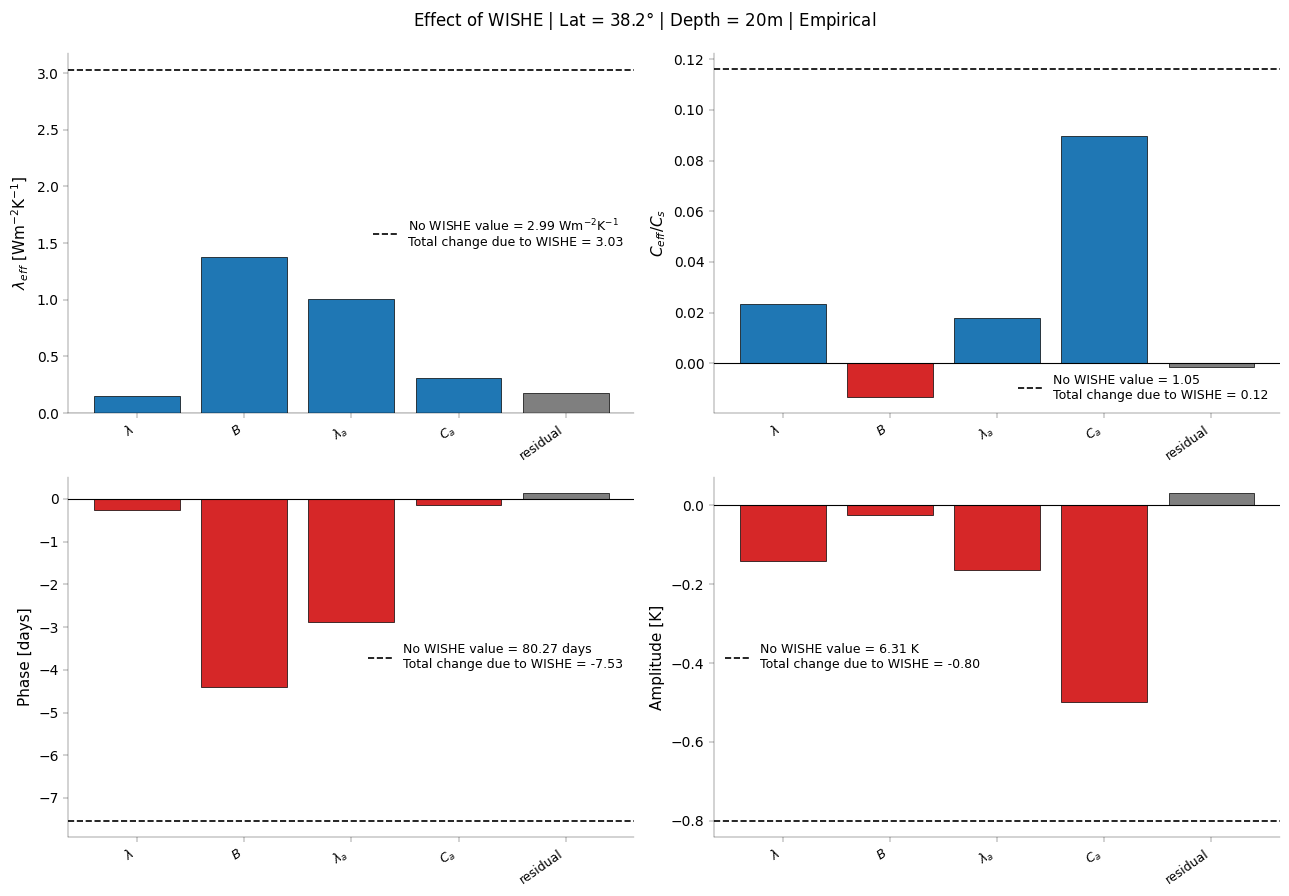

In [20]:
def plot_contribution_bars_single_exp(contributions, titles, labels_no_wishe):
    """Plots per-parameter contributions as bar charts, one per quantity, in a 2x2 grid.

    Each quantity (e.g. `lambda_eff`, `heat_cap_mult`, `coef_phase`, `coef_amp`)
    gets its own subplot with one bar per parameter (including `residual`).
    A horizontal dashed line marks the total contribution (sum of all bars),
    which equals the true difference between the two compared experiments.

    Args:
        contributions (dict): Nested dict `{quantity_name: {param_name: scalar}}`,
            where each value is a scalar or a 0-d `xarray.DataArray`.
        titles (dict, optional): Maps `quantity_name` to a subplot title.
        save_path (str): File path to save the combined PNG figure.

    Returns:
        matplotlib.figure.Figure: The combined 2x2 figure.
    """
    titles = titles or {}
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    axes = axes.flatten()

    for ax, (qty, params_dict) in zip(axes, contributions.items()):
        params = list(params_dict.keys())
        # Convert 0-d DataArrays (or plain scalars) to floats
        values = [float(v) for v in params_dict.values()]
        if qty == 'coef_phase':
            values = np.asarray(values) / omega / utils.day_seconds  # convert into a time
        total = sum(values)

        colors = ['tab:red' if v < 0 else 'tab:blue' for v in values]
        colors = [('tab:gray' if p == 'residual' else c) for p, c in zip(params, colors)]

        x = np.arange(len(params))
        ax.bar(x, values, color=colors, edgecolor='black', linewidth=0.5)

        # Total contribution marker
        ax.axhline(total, color='black', linestyle='--', linewidth=1.2,
                   label=f'No WISHE value = {labels_no_wishe[qty]}\nTotal change due to WISHE = {total:.2f}')

        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(params, rotation=35, ha='right', fontsize=9)
        ax.set_ylabel(titles.get(qty, qty), fontsize=11)
        # ax.set_title(titles.get(qty, qty), fontsize=13)
        ax.tick_params(axis='y', labelsize=10)
        ax.legend(loc='best', fontsize=9, frameon=False)

    fig.suptitle(f'Effect of WISHE | Lat = {ds.lat.values:.1f}$\degree$ | Depth = {ds.depth.values:.0f}m | {params_use.capitalize()}',
                 fontsize=12, y=0.99)
    fig.tight_layout()
    return fig
labels_no_wishe = {
    'lambda_eff': f"{lambda_s1_eff.isel(exp=0):.2f} " + 'Wm$^{-2}\\text{K}^{-1}$',
    'heat_cap_mult': f"{heat_cap_multiplier.isel(exp=0):.2f}",
    'coef_phase': f"{coef_phase.isel(exp=0) / omega / utils.day_seconds:.2f} days",
    'coef_amp': f"{coef_amp.isel(exp=0):.2f} K",
}
fig = plot_contribution_bars_single_exp(cont_diff_use, titles=titles, labels_no_wishe=labels_no_wishe)
# savefig(fig)

### Figure showing hystersis behaviour
This is used for the talk I did for my interview.

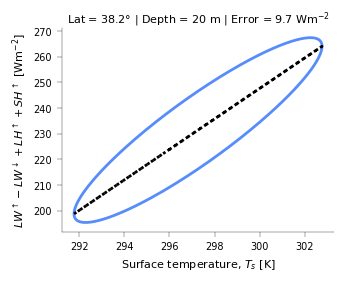

In [21]:
flux_plot = ['rh_atm']
ds_use = ds.sel(exp='wind_moist')
# flux_plot = 'msnlwrf'
simulated_alpha = 0.4
fig, ax = plt.subplots(1, len(flux_plot), sharex=True, sharey=True)
fig_resize(fig, utils.width['one_col']*1.1)
flux_net = ds_use.lwup_sfc - ds_use.lwdn_sfc + ds_use.flux_lhe + ds_use.flux_t
flux_net_linear_approx = get_fit_coef(ds_use.temp_surf, flux_net) * (ds_use.temp_surf-ds_use.temp_surf.mean(dim='time')) + flux_net.mean(dim='time')
ax.plot(ds_use.temp_surf, flux_net, lw=2)
ax.plot(ds_use.temp_surf, flux_net_linear_approx, lw=2, linestyle=':', color='k')
ax.set_ylabel('$LW^{\\uparrow}-LW^{\\downarrow} + LH^{\\uparrow} + SH^{\\uparrow}$ [Wm$^{-2}$]')
ax.set_xlabel('Surface temperature, $T_s$ [K]')
# ax[0].set_xlim(0, ds.time.size)
# ax[0].set_ylim(65, 88)
ax.set_title(f'Lat = {ds.lat.values:.1f}$\degree$ | Depth = {ds.depth.values:.0f} m | Error = {np.abs(flux_net-flux_net_linear_approx).mean(dim="time"):.1f} Wm'+'$^{-2}$', y=0.99)
plt.show()
# savefig(fig)

### Compare to a full simulation
Below I take a similar latitude in a simulation with full dynamics, but little else different. We see that the dynamic simulation has a smaller amplitude and smaller phase, than the single column simulation.

Then neglecting advection, we see the prediction for the dynamic simulation is pretty similar than to the single column case. This is indicative of a missing term in the theory - the advection term. I feel this can be accounted for just through a modification of the $B$ parameter, making it larger I think.

In [22]:
exp_dyn = 'wind_moist'
exp_name_dyn = f'thesis_season/depth={depth_use}/{exp_dyn}'
ds_dyn = isca_tools.load_dataset(exp_name_dyn, first_month_file=121).sel(lat=ds.lat, method='nearest')
ds_dyn = ds_dyn.load()
ds_dyn['p_lev'] = ds.sigma_atm.isel(exp=0) * ds_dyn.ps.mean()
ds_dyn['temp_col'] = mass_weighted_vertical_integral(ds_dyn.temp, ds_dyn.p_lev, 'pfull', simpson_method=False)
ds_dyn['sphum_col'] = mass_weighted_vertical_integral(ds_dyn.sphum, ds_dyn.p_lev, 'pfull', simpson_method=False)
ds_dyn['rh_col'] = ds_dyn['sphum_col'] / mass_weighted_vertical_integral(sphum_sat(ds_dyn.temp, ds_dyn.p_lev),
                                                                           ds_dyn.p_lev, 'pfull', simpson_method=False)
ds_dyn['p_eff'] = get_p_eff(ds_dyn.ps.mean())
ds_dyn = ds_dyn.sel(pfull=np.inf, method='nearest')
print('Loaded full ds')
ds_dyn = utils.get_annual_zonal_mean(ds_dyn)
ds_dyn['temp_col_sphum'] = get_temp_from_sphum_sat_xr(ds_dyn.sphum_col / ds_dyn.rh_col, ds_dyn.p_eff)
ds_dyn['heat_capacity'] = get_heat_capacity(c_p_ocean, rho_ocean, ds_dyn.depth)
ds_dyn = ds_dyn.rename_vars({'temp': 'temp_atm', 't_surf': 'temp_surf'})
ds_dyn = ds_dyn.expand_dims({'exp': ds.exp.sel(exp=[exp_dyn])})

Loaded full ds


In [23]:
namelist = isca_tools.load_namelist(exp_name_dyn)
# Get optical depth at surface - assume same for both experiments
odp_info = {'odp': 1, 'ir_tau_eq': 6, 'ir_tau_pole': 1.5, 'linear_tau': 0.1, 'wv_exponent': 4}  # default vals
for key in odp_info:  # If provided, update
    if key in namelist['two_stream_gray_rad_nml']:
        odp_info[key] = namelist['two_stream_gray_rad_nml'][key]
ds_dyn['odp_surf'] = opd_lw_gray(ds_dyn.lat, kappa=odp_info['odp'], tau_eq=odp_info['ir_tau_eq'],
                             tau_pole=odp_info['ir_tau_pole'], frac_linear=odp_info['linear_tau'],
                             k_exponent=odp_info['wv_exponent'])  # optical depth as function of latitude

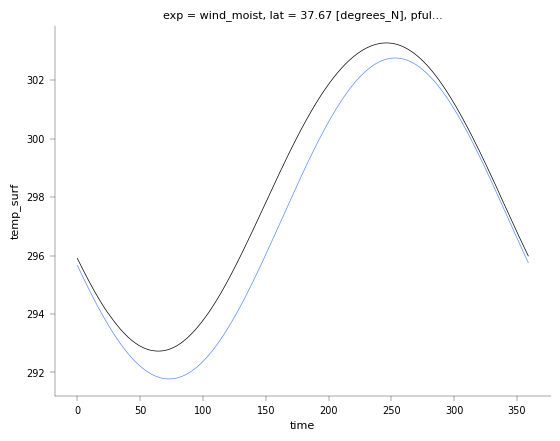

In [24]:
for i in range(ds.exp.size):
    if ds.exp.values[i] != exp_dyn:
        continue
    (ds.isel(exp=i).temp_surf-0*ds.isel(exp=i).temp_surf.mean(dim='time')).plot()
(ds_dyn.temp_surf - 0*ds_dyn.temp_surf.mean(dim='time')).plot(color='k')

In [25]:
feedback_params_dyn = {'empirical': {}, 'analytic': {}}
feedback_params_dyn['empirical']['mu'] = get_fit_coef(spline_deriv_xr(ds_dyn.time * utils.day_seconds, ds_dyn.temp_atm),
                                                  spline_deriv_xr(ds_dyn.time * utils.day_seconds,
                                                                  ds_dyn.sphum_col)) * L_v / c_p
lambda_lh_cont, feedback_params_dyn['empirical']['lambda_lh'] = get_fit_coef(ds_dyn.temp_surf - ds_dyn.temp_atm, ds_dyn.flux_lhe,
                                                                         ds_dyn.temp_atm)
lambda_sh_cont, feedback_params_dyn['empirical']['lambda_sh'] = get_fit_coef(ds_dyn.temp_surf - ds_dyn.temp_atm, ds_dyn.flux_t,
                                                                         -ds_dyn.temp_atm)
lambda_lw_cont, feedback_params_dyn['empirical']['lambda_lw2'] = get_fit_coef(ds_dyn.temp_surf - ds_dyn.temp_atm,
                                                                          ds_dyn.lwup_sfc - ds_dyn.lwdn_sfc, ds_dyn.temp_atm)
feedback_params_dyn['empirical']['lambda_const'] = lambda_lh_cont + lambda_sh_cont + lambda_lw_cont
olr_surf_cont = Stefan_Boltzmann * np.exp(-ds_dyn.odp_surf) * ds_dyn.temp_surf ** 4
feedback_params_dyn['empirical']['lambda_lw1'] = get_fit_coef(ds_dyn.temp_surf, olr_surf_cont)
feedback_params_dyn['empirical']['B'], feedback_params_dyn['empirical']['coef_phase_olr'] = \
    utils.get_fit_coef_complex(ds_dyn.olr - olr_surf_cont, ds_dyn.temp_atm, ds_dyn.time)
feedback_params_dyn['empirical']['coef_amp_col'] = coef_temp['amp']['col']
feedback_params_dyn['empirical']['coef_phase_col'] = coef_temp['phase']['col']
#feedback_params_dyn['empirical'] = {key: feedback_params['empirical'][key].isel(exp=[0]) for key in feedback_params['analytic'].keys()}

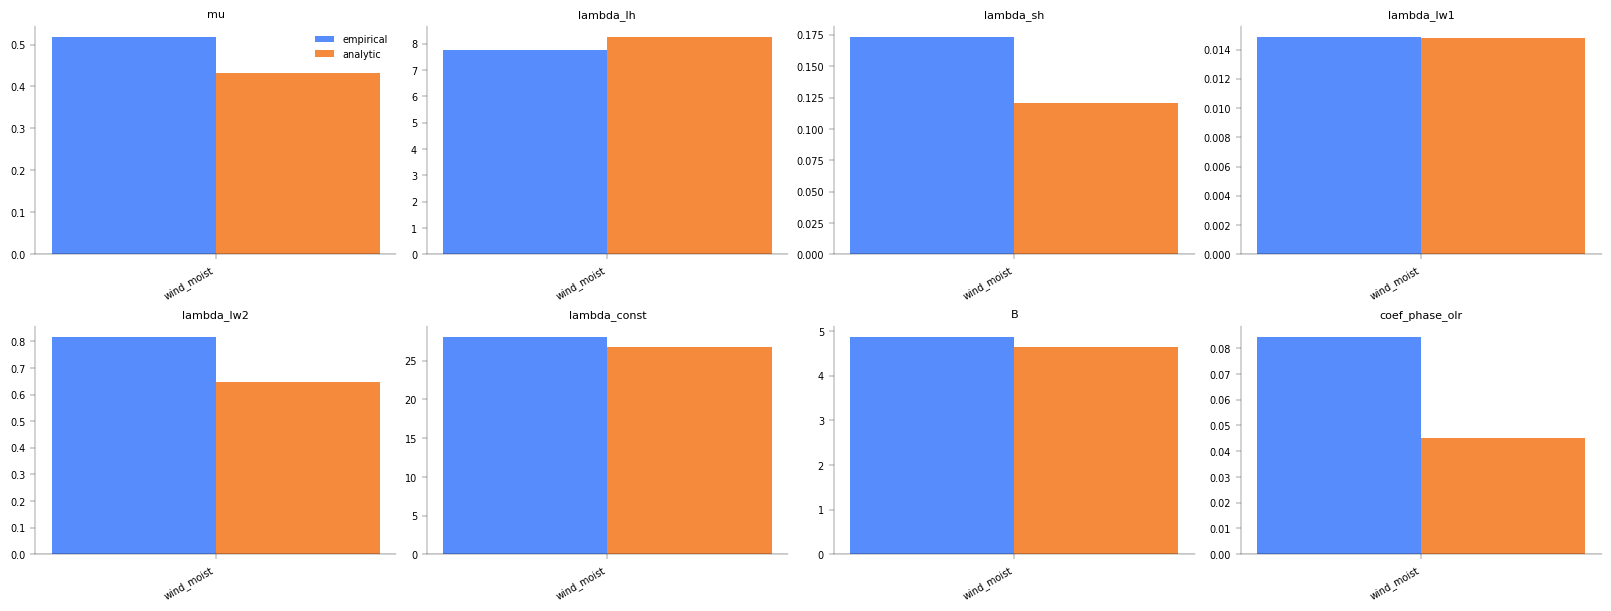

In [26]:
# Blue show dynamic values, orange shows single column values
feedback_params_dyn['analytic'] = {key: feedback_params['analytic'][key].sel(exp=[exp_dyn]) for key in feedback_params['analytic'].keys()}
fig, axs = plot_feedback_params(feedback_params_dyn,
                                params=['mu', 'lambda_lh', 'lambda_sh', 'lambda_lw1', 'lambda_lw2', 'lambda_const', 'B',
                                        'coef_phase_olr'], ncols=4)

In [27]:
_, coef_amp_dyn, coef_phase_dyn = get_fourier_fit_xr(ds_dyn.time, ds_dyn.temp_surf, n_harmonics=1, pad_coefs_phase=True)
_, coef_sw_amp_dyn, coef_sw_phase_dyn = get_fourier_fit_xr(ds_dyn.time, ds_dyn.swdn_sfc, n_harmonics=1, pad_coefs_phase=True)
coef_amp_dyn = np.abs(coef_amp_dyn.sel(harmonic=1))
coef_phase_dyn = coef_phase_dyn.sel(harmonic=1)
coef_sw_amp_dyn = np.abs(coef_sw_amp_dyn.sel(harmonic=1))

heat_cap_multiplier_dyn = get_heat_capacity(c_p_ocean, rho_ocean,
                                        coef_sw_amp_dyn * np.sin(coef_phase_dyn) / (2 * np.pi * f) / coef_amp_dyn,
                                        True) / ds_dyn.depth
heat_capacity_eff_dyn = ds_dyn.heat_capacity * heat_cap_multiplier_dyn
lambda_s1_eff_dyn = coef_sw_amp_dyn * np.cos(coef_phase_dyn) / coef_amp_dyn

In [28]:
lambda_eff_theory_dyn, heat_cap_multiplier_theory_dyn, coef_phase_theory_dyn, coef_amp_theory_dyn = \
    get_theory_quantities(feedback_params_dyn['empirical'])
tan_phase_theory_dyn = np.tan(coef_phase_theory_dyn)
heat_capacity_eff_theory_dyn = heat_cap_multiplier_theory_dyn * ds_dyn.heat_capacity

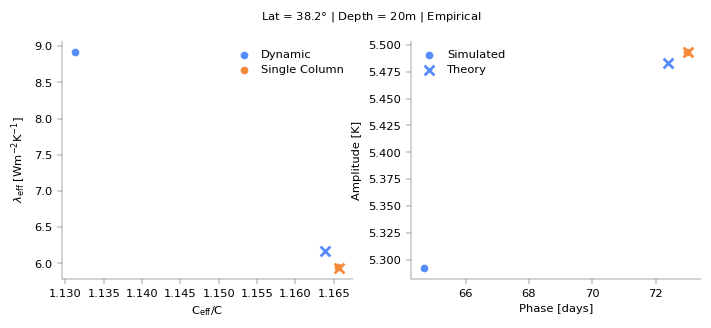

In [29]:
show_phase_time = True
fig, ax = plt.subplots(1, 2)
fig_resize(fig, utils.width['two_col'] * 1.5)
for i in [exp_dyn]:
    ax[0].scatter(heat_cap_multiplier_dyn.sel(exp=i), lambda_s1_eff_dyn.sel(exp=i), color=f'C0',
                  marker='.', s=50, lw=2, label='Dynamic')
    ax[0].scatter(heat_cap_multiplier_theory_dyn.sel(exp=i), lambda_eff_theory_dyn.sel(exp=i),
                  color=f'C0', marker='x', s=50, lw=2)
    ax[1].scatter(coef_phase_dyn.sel(exp=i) / omega / utils.day_seconds if show_phase_time else
                  (omega * heat_capacity_eff_dyn / lambda_s1_eff_dyn).sel(exp=i), coef_amp_dyn.sel(exp=i),
                  color=f'C0', marker='.', s=50, lw=2, label='Simulated')
    ax[1].scatter(np.arctan(tan_phase_theory_dyn).sel(exp=i) / omega / utils.day_seconds if show_phase_time else
                  tan_phase_theory_dyn.sel(exp=i), coef_amp_theory_dyn.sel(exp=i),
                  color=f'C0', marker='x', s=50, lw=2, label='Theory')

    ax[0].scatter(heat_cap_multiplier.sel(exp=i), lambda_s1_eff.sel(exp=i), color=f'C1',
                  marker='.', s=50, lw=2, label='Single Column')
    ax[0].scatter(heat_cap_multiplier_theory.sel(exp=i), lambda_eff_theory.sel(exp=i),
                  color=f'C1', marker='x', s=50, lw=2)
    ax[1].scatter(coef_phase.sel(exp=i) / omega / utils.day_seconds if show_phase_time else
                  (omega * heat_capacity_eff / lambda_s1_eff).sel(exp=i), coef_amp.sel(exp=i),
                  color=f'C1', marker='.', s=50, lw=2, label='Simulated' if i == 0 else None)
    ax[1].scatter(np.arctan(tan_phase_theory).sel(exp=i) / omega / utils.day_seconds if show_phase_time else
                  tan_phase_theory.sel(exp=i), coef_amp_theory.sel(exp=i),
                  color=f'C1', marker='x', s=50, lw=2, label='Theory' if i == 0 else None)
    # ax[0].plot(ds.lat, heat_cap_multiplier_theory.isel(exp=i), color=f'C{i}', linestyle=':')
    # ax[1].plot(ds.lat, lambda_s1_eff.isel(exp=i), color=f'C{i}', label='Simulated' if i == 0 else None)
    # ax[1].plot(ds.lat, lambda_s1_eff_theory.isel(exp=i), color=f'C{i}', linestyle=':',
    #            label='Theory' if i == 0 else None)
update_linewidth(fig)
ax[0].legend()
ax[1].legend()
ax[0].set_xlabel("C$_{\\text{eff}}/$C")
ax[0].set_ylabel("$\lambda_{\\text{eff}}$ [Wm$^{-2}\\text{K}^{-1}$]")
ax[1].set_xlabel("Phase [days]" if show_phase_time else "$\\tan (\\phi)$")
ax[1].set_ylabel("Amplitude [K]")
fig.suptitle(f'Lat = {ds.lat.values:.1f}$\degree$ | Depth = {ds.depth.values:.0f}m | {params_use.capitalize()}')
update_fontsize(fig, 7)
plt.show()